# Apartado 3. Comparación de las medias trimestrales de la irradiación, la temperatura y la precipitación en la celda 01.


**NOTA DE ESTRUCTURA:** La introducción metodológica general del apartado 3 se incorpora explícitamente al inicio del subapartado 3.1 para mantener el mismo estilo narrativo usado en los apartados anteriores del informe.

## Importación y carga de datos

En esta sección se importan los datos y librerías necesarias para el análisis del apartado 3.

In [1]:
from carga_de_datos import *
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
from pathlib import Path
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'src' else Path.cwd()
IMAGES_DIR = PROJECT_ROOT / 'images'
IMAGES_DIR.mkdir(parents=True, exist_ok=True)

Tamaño de df_orig_temp con los datos cargados: (4383, 15)
Dataframe con todos los datos leidos (filas: días, columnas: variables):
           FECHA  TEMP_CELDA01  TEMP_CELDA02  TEMP_CELDA03  TEMP_CELDA04  \
0     2014-01-01      9.304810      9.234131      9.134725      8.917480   
1     2014-01-02     11.986209     11.888858     11.768883     11.706729   
2     2014-01-03     13.474006     13.405910     13.308051     13.187058   
3     2014-01-04     11.460185     11.400940     11.306010     11.271545   
4     2014-01-05      7.990672      8.004791      7.974009      7.590749   
...          ...           ...           ...           ...           ...   
4378  2025-12-27      6.853189      6.883666      6.892943      6.586832   
4379  2025-12-28      8.640758      8.662160      8.675710      8.074249   
4380  2025-12-29      7.409761      7.522859      7.593782      6.951753   
4381  2025-12-30      8.605798      8.644759      8.652287      7.629785   
4382  2025-12-31      7.655819   

## 3.1. Calcular los intervalos de confianza para la media de los datos de irradiación de la celda 01 por trimestres mediante Bootstrap, con un nivel de confianza del 50% y del 99%. ¿Para qué pares de trimestres se solapan sus respectivos intervalos de confianza? ¿La respuesta a la pregunta anterior depende del nivel de confianza?

Al igual que en los apartados 1 y 2, el análisis se presenta en formato técnico y posteriormente en formato interpretativo para informe. En este primer subapartado se fija la metodología común del apartado 3: se estiman intervalos de confianza bootstrap BCa para la media trimestral (niveles 50% y 99%), se comparan los solapes entre pares de trimestres y se valida la interpretación con las gráficas de evaluación y de distribución bootstrap.

In [2]:
print('En primer lugar definimos los parámetros comunes de Bootstrap que reutilizaremos en todo el apartado.')
R = 9999
estadistico = np.mean
niveles_confianza = [0.50, 0.99]
nivel_confianza_adicional = 0.30

En primer lugar definimos los parámetros comunes de Bootstrap que reutilizaremos en todo el apartado.


In [3]:
print('En segundo lugar preparamos los datos de irradiación por trimestres en la celda 01.')
df_irrad = df_orig_irrad.copy()
df_irrad['FECHA'] = pd.to_datetime(df_irrad['FECHA'])
df_irrad['TRIMESTRE'] = df_irrad['FECHA'].dt.quarter

En segundo lugar preparamos los datos de irradiación por trimestres en la celda 01.


In [4]:
print('En tercer lugar calculamos los intervalos de confianza Bootstrap y construimos la tabla de irradiación.')
resultados_irrad = []
dist_boot_irrad_99 = {}

for trimestre in sorted(df_irrad['TRIMESTRE'].unique()):
    x = df_irrad.loc[df_irrad['TRIMESTRE'] == trimestre, 'IRRAD_CELDA01'].to_numpy(dtype=float)
    fila = {'Trimestre': f'T{trimestre}', 'Media': np.mean(x)}

    for nivel_confianza in [nivel_confianza_adicional, *niveles_confianza]:
        muestra_orig = (x,)
        res_BCa = stats.bootstrap(
            muestra_orig,
            estadistico,
            confidence_level=nivel_confianza,
            n_resamples=R,
            method='BCA',
            random_state=999,
        )
        lim_inf_BCa, lim_sup_BCa = res_BCa.confidence_interval
        fila[f'IC {int(100 * nivel_confianza)}%'] = (lim_inf_BCa, lim_sup_BCa)

        if nivel_confianza == 0.99:
            dist_boot_irrad_99[f'T{trimestre}'] = np.array(res_BCa.bootstrap_distribution, dtype=float)

    resultados_irrad.append(fila)

tabla_irrad = pd.DataFrame(resultados_irrad)
print('\nTabla de intervalos bootstrap para irradiación:')
print(tabla_irrad[['Trimestre', 'Media', 'IC 30%', 'IC 50%', 'IC 99%']])

En tercer lugar calculamos los intervalos de confianza Bootstrap y construimos la tabla de irradiación.

Tabla de intervalos bootstrap para irradiación:
  Trimestre         Media                                    IC 30%  \
0        T1  5.265756e+05    (523931.10509448964, 528948.495592931)   
1        T2  1.025743e+06  (1022853.7459096661, 1028321.8373586396)   
2        T3  1.030350e+06  (1027898.6985582627, 1032476.5455209943)   
3        T4  4.384121e+05   (436477.47454584343, 440495.6350440092)   

                                     IC 50%  \
0   (522077.39115084906, 530817.9930921276)   
1  (1020845.8313355838, 1030302.5527043877)   
2  (1026135.4577978313, 1034145.5482538269)   
3    (434991.8935770466, 441963.4905692356)   

                                     IC 99%  
0    (510155.8595934368, 542941.7166840835)  
1  (1006780.3454405599, 1043105.2449932871)  
2   (1014412.486846003, 1045189.3060764387)  
3   (425046.4819419641, 452213.59013863734)  


En cuarto lugar representamos gráficamente los intervalos de confianza Bootstrap de la irradiación por trimestres.


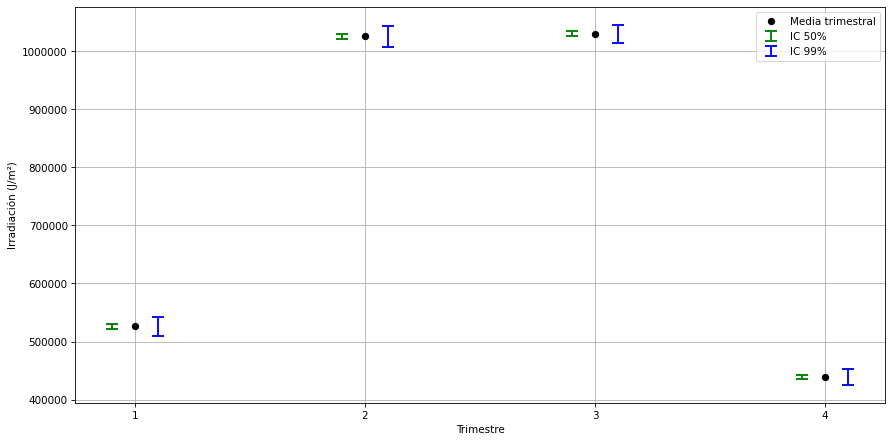

In [5]:
print('En cuarto lugar representamos gráficamente los intervalos de confianza Bootstrap de la irradiación por trimestres.')
trimestres = tabla_irrad['Trimestre'].tolist()
x_pos = np.arange(1, len(trimestres) + 1)
medias = tabla_irrad['Media'].to_numpy(dtype=float)

delta = 0.10
lim_inf_50 = tabla_irrad['IC 50%'].apply(lambda z: z[0]).to_numpy(dtype=float)
lim_sup_50 = tabla_irrad['IC 50%'].apply(lambda z: z[1]).to_numpy(dtype=float)
lim_inf_99 = tabla_irrad['IC 99%'].apply(lambda z: z[0]).to_numpy(dtype=float)
lim_sup_99 = tabla_irrad['IC 99%'].apply(lambda z: z[1]).to_numpy(dtype=float)
from matplotlib.ticker import ScalarFormatter

fig = plt.figure(figsize=(12, 6))
plt.plot(x_pos, medias, 'o', color='black', markersize=6, label='Media trimestral')

yerr_50 = np.vstack((medias - lim_inf_50, lim_sup_50 - medias))
yerr_99 = np.vstack((medias - lim_inf_99, lim_sup_99 - medias))

plt.errorbar(x_pos - delta, medias, yerr=yerr_50, fmt='none', ecolor='green', elinewidth=1.8, capsize=6, capthick=1.8, label='IC 50%')
plt.errorbar(x_pos + delta, medias, yerr=yerr_99, fmt='none', ecolor='blue', elinewidth=1.8, capsize=6, capthick=1.8, label='IC 99%')

plt.xlabel('Trimestre')
plt.ylabel('Irradiación (J/m²)')
plt.xticks(x_pos, trimestres)
plt.legend()
plt.grid()
ax_main = plt.gca()
fmt_x_main = ScalarFormatter(useOffset=False)
fmt_x_main.set_scientific(False)
fmt_y_main = ScalarFormatter(useOffset=False)
fmt_y_main.set_scientific(False)
ax_main.xaxis.set_major_formatter(fmt_x_main)
ax_main.yaxis.set_major_formatter(fmt_y_main)

plt.tight_layout()
plt.savefig(IMAGES_DIR / 'Gráfico 3.1： Intervalos de confianza Bootstrap de la irradiación por trimestres en celda 01.png', dpi=300, bbox_inches='tight')
plt.show()

En quinto lugar representamos, para cada trimestre, la distribución bootstrap de la media junto con la distribución estimada, el IC 99%, la zona crítica al 50% y las bandas inferiores para IC 99% e IC 30%.


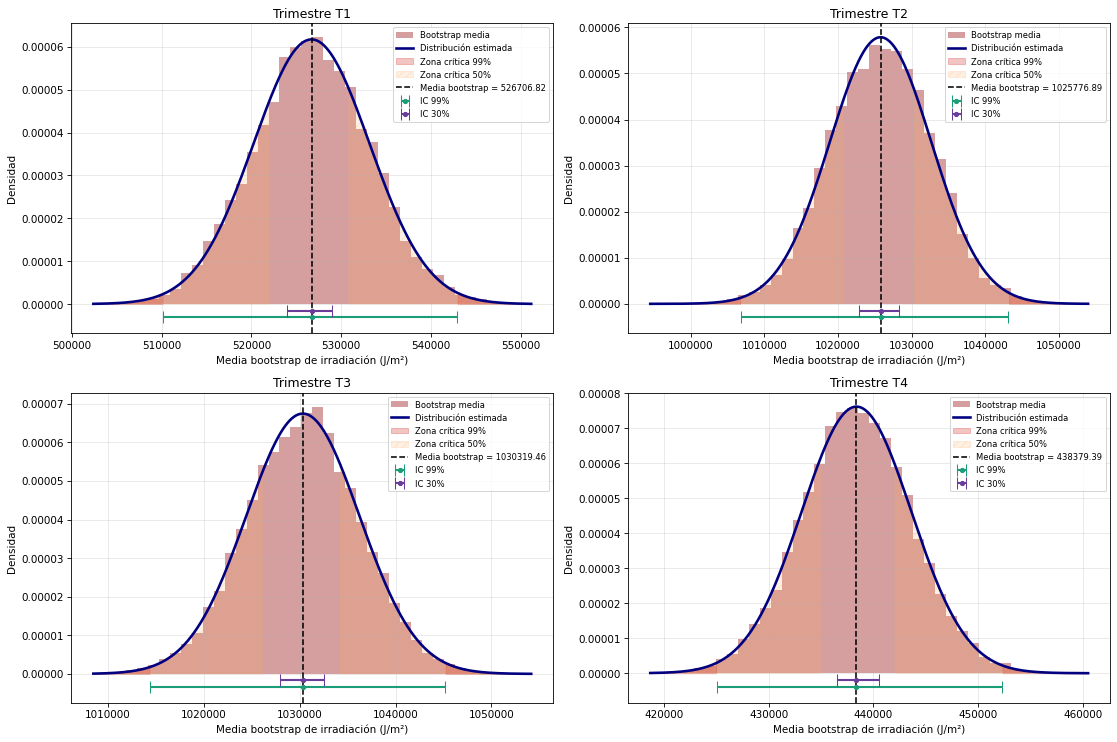

In [6]:
print('En quinto lugar representamos, para cada trimestre, la distribución bootstrap de la media junto con la distribución estimada, el IC 99%, la zona crítica al 50% y las bandas inferiores para IC 99% e IC 30%.')
fig = plt.figure(2, figsize=(15, 10))
for idx, trimestre in enumerate(trimestres, start=1):
    valores_boot = dist_boot_irrad_99[trimestre]
    mu_hat = np.mean(valores_boot)
    sigma_hat = np.std(valores_boot, ddof=1)

    lim_inf_99_t, lim_sup_99_t = tabla_irrad.loc[tabla_irrad['Trimestre'] == trimestre, 'IC 99%'].iloc[0]
    lim_inf_50_t, lim_sup_50_t = tabla_irrad.loc[tabla_irrad['Trimestre'] == trimestre, 'IC 50%'].iloc[0]
    lim_inf_30_t, lim_sup_30_t = tabla_irrad.loc[tabla_irrad['Trimestre'] == trimestre, 'IC 30%'].iloc[0]

    xs = np.linspace(np.min(valores_boot), np.max(valores_boot), 400)
    densidad_est = stats.norm.pdf(xs, loc=mu_hat, scale=sigma_hat)

    ax = plt.subplot(2, 2, idx)
    ax.hist(valores_boot, density=True, bins=40, color='brown', alpha=0.45, label='Bootstrap media')
    ax.plot(xs, densidad_est, color='navy', linewidth=2.5, label='Distribución estimada')

    xs_crit_99_izq = xs[xs < lim_inf_99_t]
    xs_crit_99_der = xs[xs > lim_sup_99_t]
    if xs_crit_99_izq.size > 0:
        ax.fill_between(xs_crit_99_izq, stats.norm.pdf(xs_crit_99_izq, loc=mu_hat, scale=sigma_hat), color='#d73027', alpha=0.28, label='Zona crítica 99%')
    if xs_crit_99_der.size > 0:
        ax.fill_between(xs_crit_99_der, stats.norm.pdf(xs_crit_99_der, loc=mu_hat, scale=sigma_hat), color='#d73027', alpha=0.28)

    xs_crit_50_izq = xs[xs < lim_inf_50_t]
    xs_crit_50_der = xs[xs > lim_sup_50_t]
    if xs_crit_50_izq.size > 0:
        ax.fill_between(xs_crit_50_izq, stats.norm.pdf(xs_crit_50_izq, loc=mu_hat, scale=sigma_hat), facecolor='#fdae61', edgecolor='#fdae61', alpha=0.18, hatch='///', label='Zona crítica 50%')
    if xs_crit_50_der.size > 0:
        ax.fill_between(xs_crit_50_der, stats.norm.pdf(xs_crit_50_der, loc=mu_hat, scale=sigma_hat), facecolor='#fdae61', edgecolor='#fdae61', alpha=0.18, hatch='///')

    ax.axvline(mu_hat, color='black', linestyle='--', linewidth=1.5, label=f'Media bootstrap = {mu_hat:.2f}')
    y_ic_99 = -0.05 * np.max(densidad_est)
    y_ic_30 = -0.025 * np.max(densidad_est)
    ax.errorbar(mu_hat, y_ic_99, xerr=np.array([[mu_hat - lim_inf_99_t], [lim_sup_99_t - mu_hat]]), fmt='o', color='#1b9e77', ecolor='#1b9e77', capsize=6, elinewidth=2.0, markersize=4, label='IC 99%')
    ax.errorbar(mu_hat, y_ic_30, xerr=np.array([[mu_hat - lim_inf_30_t], [lim_sup_30_t - mu_hat]]), fmt='o', color='#6a3d9a', ecolor='#6a3d9a', capsize=6, elinewidth=2.0, markersize=4, label='IC 30%')

    ax.set_ylim(bottom=2.2 * y_ic_99)
    ax.set_xlabel('Media bootstrap de irradiación (J/m²)')
    ax.set_ylabel('Densidad')
    ax.set_title(f'Trimestre {trimestre}')
    ax.grid(alpha=0.3)
    fmt_x = ScalarFormatter(useOffset=False)
    fmt_x.set_scientific(False)
    fmt_y = ScalarFormatter(useOffset=False)
    fmt_y.set_scientific(False)
    ax.xaxis.set_major_formatter(fmt_x)
    ax.yaxis.set_major_formatter(fmt_y)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(IMAGES_DIR / 'Gráfico 3.2： Distribución bootstrap, distribución estimada, IC 50% y 99% y zonas críticas de irradiación por trimestres en celda 01.png', dpi=300, bbox_inches='tight')
plt.show()

In [7]:
print('En cuarto lugar evaluamos qué pares de trimestres solapan para cada nivel de confianza.')
solapes_por_ic = {}
for nivel_confianza in niveles_confianza:
    pares_solape = []
    etiqueta = f'IC {int(100 * nivel_confianza)}%'

    for i in range(len(tabla_irrad)):
        for j in range(i + 1, len(tabla_irrad)):
            a1, b1 = tabla_irrad.loc[i, etiqueta]
            a2, b2 = tabla_irrad.loc[j, etiqueta]
            if not (b1 < a2 or b2 < a1):
                pares_solape.append(f"{tabla_irrad.loc[i, 'Trimestre']}-{tabla_irrad.loc[j, 'Trimestre']}")

    solapes_por_ic[etiqueta] = set(pares_solape)

    if len(pares_solape) > 0:
        print(f"\nPares con solape para {etiqueta}: {', '.join(pares_solape)}")
    else:
        print(f"\nNo hay pares con solape para {etiqueta}.")

etiquetas = [f'IC {int(100 * nc)}%' for nc in niveles_confianza]
depende_irrad = solapes_por_ic[etiquetas[0]] != solapes_por_ic[etiquetas[1]]

pares_50_irrad = sorted(solapes_por_ic['IC 50%'])
pares_99_irrad = sorted(solapes_por_ic['IC 99%'])
texto_50_irrad = ', '.join(pares_50_irrad) if len(pares_50_irrad) > 0 else 'ninguno'
texto_99_irrad = ', '.join(pares_99_irrad) if len(pares_99_irrad) > 0 else 'ninguno'

if depende_irrad:
    print('\nConclusión: para irradiación, la respuesta sí depende del nivel de confianza.')
    interpretacion_irrad = 'Los conjuntos de solape no coinciden entre 50% y 99%, por lo que la inferencia cambia al modificar el nivel de confianza.'
else:
    print('\nConclusión: para irradiación, la respuesta no depende del nivel de confianza.')
    interpretacion_irrad = 'Los conjuntos de solape son iguales en ambos niveles, por lo que la conclusión se mantiene estable frente al cambio de confianza.'

print("\nAnálisis del subapartado 3.1 - IC bootstrap de la media de irradiación por trimestres (celda 01) y evaluación de solapes para 50% y 99%:\n"
      f"Con un nivel de confianza del 50%, los pares con solape son: {texto_50_irrad}.\n"
      f"Con un nivel de confianza del 99%, los pares con solape son: {texto_99_irrad}.\n"
      f"{interpretacion_irrad}\n"
      "La representación con barras de error facilita esta lectura, especialmente en los trimestres con intervalos estrechos.")

En cuarto lugar evaluamos qué pares de trimestres solapan para cada nivel de confianza.

Pares con solape para IC 50%: T2-T3

Pares con solape para IC 99%: T2-T3

Conclusión: para irradiación, la respuesta no depende del nivel de confianza.

Análisis del subapartado 3.1 - IC bootstrap de la media de irradiación por trimestres (celda 01) y evaluación de solapes para 50% y 99%:
Con un nivel de confianza del 50%, los pares con solape son: T2-T3.
Con un nivel de confianza del 99%, los pares con solape son: T2-T3.
Los conjuntos de solape son iguales en ambos niveles, por lo que la conclusión se mantiene estable frente al cambio de confianza.
La representación con barras de error facilita esta lectura, especialmente en los trimestres con intervalos estrechos.


## 3.2. Calcular los intervalos de confianza para la media de los datos de temperatura de la celda 01 por trimestres mediante Bootstrap, con un nivel de confianza del 50% y del 99%. ¿Para qué pares de trimestres se solapan sus respectivos intervalos de confianza? ¿La respuesta a la pregunta anterior depende del nivel de confianza?

Al igual que en el subapartado 3.1, se aplica el mismo esquema de trabajo: estimación de IC bootstrap BCa (50% y 99%), identificación de pares con solape y contraste visual mediante las figuras del subapartado.

In [8]:
print('En primer lugar preparamos los datos de temperatura por trimestres en la celda 01.')
df_temp = df_orig_temp.copy()
df_temp['FECHA'] = pd.to_datetime(df_temp['FECHA'])
df_temp['TRIMESTRE'] = df_temp['FECHA'].dt.quarter

print('En segundo lugar calculamos los intervalos de confianza Bootstrap y construimos la tabla de temperatura.')
resultados_temp = []
dist_boot_temp_99 = {}

for trimestre in sorted(df_temp['TRIMESTRE'].unique()):
    x = df_temp.loc[df_temp['TRIMESTRE'] == trimestre, 'TEMP_CELDA01'].to_numpy(dtype=float)
    fila = {'Trimestre': f'T{trimestre}', 'Media': np.mean(x)}

    for nivel_confianza in [nivel_confianza_adicional, *niveles_confianza]:
        muestra_orig = (x,)
        res_BCa = stats.bootstrap(
            muestra_orig,
            estadistico,
            confidence_level=nivel_confianza,
            n_resamples=R,
            method='BCA',
            random_state=999,
        )
        lim_inf_BCa, lim_sup_BCa = res_BCa.confidence_interval
        fila[f'IC {int(100 * nivel_confianza)}%'] = (lim_inf_BCa, lim_sup_BCa)

        if nivel_confianza == 0.99:
            dist_boot_temp_99[f'T{trimestre}'] = np.array(res_BCa.bootstrap_distribution, dtype=float)

    resultados_temp.append(fila)

tabla_temp = pd.DataFrame(resultados_temp)
print('\nTabla de intervalos bootstrap para temperatura:')
print(tabla_temp[['Trimestre', 'Media', 'IC 30%', 'IC 50%', 'IC 99%']])

En primer lugar preparamos los datos de temperatura por trimestres en la celda 01.
En segundo lugar calculamos los intervalos de confianza Bootstrap y construimos la tabla de temperatura.

Tabla de intervalos bootstrap para temperatura:
  Trimestre      Media                                    IC 30%  \
0        T1  10.698915   (10.658202209357091, 10.73550958221619)   
1        T2  21.230702    (21.1712292271034, 21.295470739296448)   
2        T3  28.164456  (28.120322236930434, 28.207393143887796)   
3        T4  14.274837  (14.214820285152305, 14.334831207831877)   

                                     IC 50%  \
0  (10.629985292286133, 10.763913836599997)   
1   (21.12147852529385, 21.345113871170906)   
2  (28.087024845698586, 28.239550889988152)   
3  (14.172110120681612, 14.380438950018856)   

                                     IC 99%  
0  (10.443273066154118, 10.952037517708261)  
1  (20.807805388812824, 21.651667994509314)  
2     (27.8655270576413, 28.45557196860245)  
3 

En tercer lugar representamos gráficamente los intervalos de confianza Bootstrap de la temperatura por trimestres.


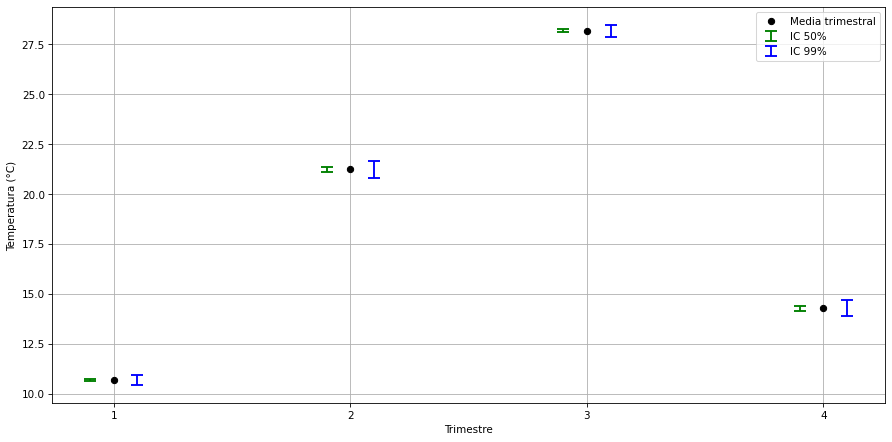

In [9]:
print('En tercer lugar representamos gráficamente los intervalos de confianza Bootstrap de la temperatura por trimestres.')
trimestres = tabla_temp['Trimestre'].tolist()
x_pos = np.arange(1, len(trimestres) + 1)
medias = tabla_temp['Media'].to_numpy(dtype=float)

delta = 0.10
lim_inf_50 = tabla_temp['IC 50%'].apply(lambda z: z[0]).to_numpy(dtype=float)
lim_sup_50 = tabla_temp['IC 50%'].apply(lambda z: z[1]).to_numpy(dtype=float)
lim_inf_99 = tabla_temp['IC 99%'].apply(lambda z: z[0]).to_numpy(dtype=float)
lim_sup_99 = tabla_temp['IC 99%'].apply(lambda z: z[1]).to_numpy(dtype=float)
from matplotlib.ticker import ScalarFormatter

fig = plt.figure(figsize=(12, 6))
plt.plot(x_pos, medias, 'o', color='black', markersize=6, label='Media trimestral')

yerr_50 = np.vstack((medias - lim_inf_50, lim_sup_50 - medias))
yerr_99 = np.vstack((medias - lim_inf_99, lim_sup_99 - medias))

plt.errorbar(x_pos - delta, medias, yerr=yerr_50, fmt='none', ecolor='green', elinewidth=1.8, capsize=6, capthick=1.8, label='IC 50%')
plt.errorbar(x_pos + delta, medias, yerr=yerr_99, fmt='none', ecolor='blue', elinewidth=1.8, capsize=6, capthick=1.8, label='IC 99%')

plt.xlabel('Trimestre')
plt.ylabel('Temperatura (°C)')
plt.xticks(x_pos, trimestres)
plt.legend()
plt.grid()
ax_main = plt.gca()
fmt_x_main = ScalarFormatter(useOffset=False)
fmt_x_main.set_scientific(False)
fmt_y_main = ScalarFormatter(useOffset=False)
fmt_y_main.set_scientific(False)
ax_main.xaxis.set_major_formatter(fmt_x_main)
ax_main.yaxis.set_major_formatter(fmt_y_main)

plt.tight_layout()
plt.savefig(IMAGES_DIR / 'Gráfico 3.3： Intervalos de confianza Bootstrap de la temperatura por trimestres en celda 01.png', dpi=300, bbox_inches='tight')
plt.show()

En cuarto lugar representamos, para cada trimestre, la distribución bootstrap de la media junto con la distribución estimada, el IC 99%, la zona crítica al 50% y las bandas inferiores para IC 99% e IC 30%.


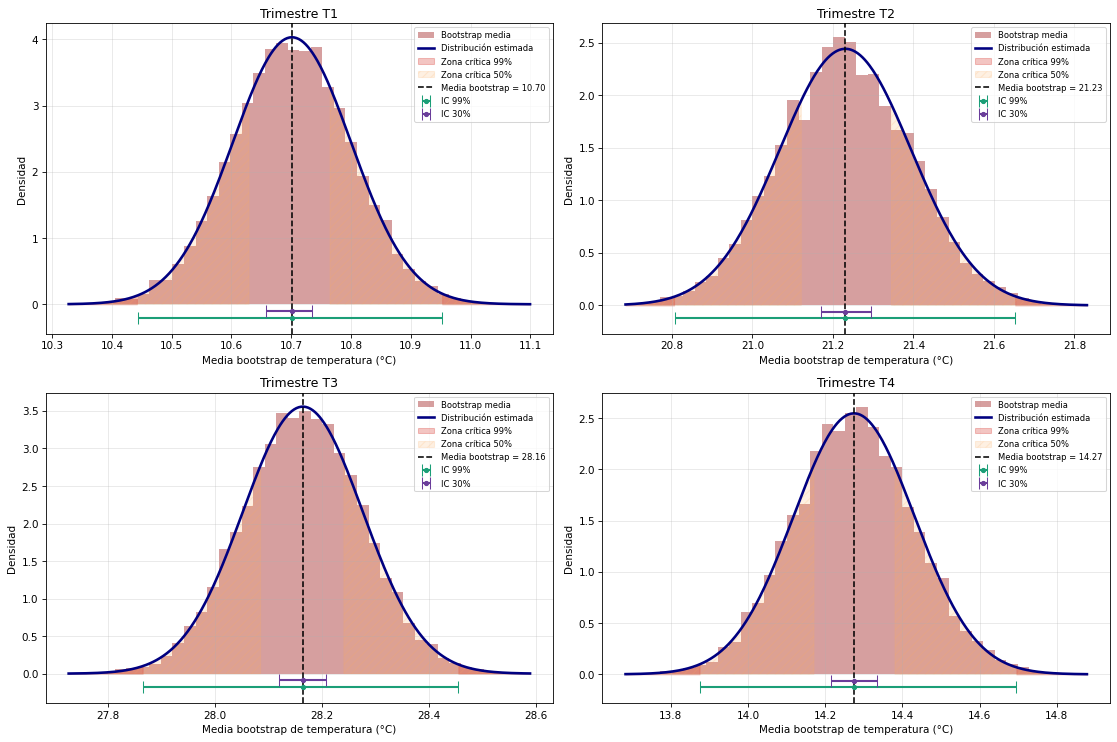

In [10]:
print('En cuarto lugar representamos, para cada trimestre, la distribución bootstrap de la media junto con la distribución estimada, el IC 99%, la zona crítica al 50% y las bandas inferiores para IC 99% e IC 30%.')
fig = plt.figure(2, figsize=(15, 10))
for idx, trimestre in enumerate(trimestres, start=1):
    valores_boot = dist_boot_temp_99[trimestre]
    mu_hat = np.mean(valores_boot)
    sigma_hat = np.std(valores_boot, ddof=1)

    lim_inf_99_t, lim_sup_99_t = tabla_temp.loc[tabla_temp['Trimestre'] == trimestre, 'IC 99%'].iloc[0]
    lim_inf_50_t, lim_sup_50_t = tabla_temp.loc[tabla_temp['Trimestre'] == trimestre, 'IC 50%'].iloc[0]
    lim_inf_30_t, lim_sup_30_t = tabla_temp.loc[tabla_temp['Trimestre'] == trimestre, 'IC 30%'].iloc[0]

    xs = np.linspace(np.min(valores_boot), np.max(valores_boot), 400)
    densidad_est = stats.norm.pdf(xs, loc=mu_hat, scale=sigma_hat)

    ax = plt.subplot(2, 2, idx)
    ax.hist(valores_boot, density=True, bins=40, color='brown', alpha=0.45, label='Bootstrap media')
    ax.plot(xs, densidad_est, color='navy', linewidth=2.5, label='Distribución estimada')

    xs_crit_99_izq = xs[xs < lim_inf_99_t]
    xs_crit_99_der = xs[xs > lim_sup_99_t]
    if xs_crit_99_izq.size > 0:
        ax.fill_between(xs_crit_99_izq, stats.norm.pdf(xs_crit_99_izq, loc=mu_hat, scale=sigma_hat), color='#d73027', alpha=0.28, label='Zona crítica 99%')
    if xs_crit_99_der.size > 0:
        ax.fill_between(xs_crit_99_der, stats.norm.pdf(xs_crit_99_der, loc=mu_hat, scale=sigma_hat), color='#d73027', alpha=0.28)

    xs_crit_50_izq = xs[xs < lim_inf_50_t]
    xs_crit_50_der = xs[xs > lim_sup_50_t]
    if xs_crit_50_izq.size > 0:
        ax.fill_between(xs_crit_50_izq, stats.norm.pdf(xs_crit_50_izq, loc=mu_hat, scale=sigma_hat), facecolor='#fdae61', edgecolor='#fdae61', alpha=0.18, hatch='///', label='Zona crítica 50%')
    if xs_crit_50_der.size > 0:
        ax.fill_between(xs_crit_50_der, stats.norm.pdf(xs_crit_50_der, loc=mu_hat, scale=sigma_hat), facecolor='#fdae61', edgecolor='#fdae61', alpha=0.18, hatch='///')

    ax.axvline(mu_hat, color='black', linestyle='--', linewidth=1.5, label=f'Media bootstrap = {mu_hat:.2f}')
    y_ic_99 = -0.05 * np.max(densidad_est)
    y_ic_30 = -0.025 * np.max(densidad_est)
    ax.errorbar(mu_hat, y_ic_99, xerr=np.array([[mu_hat - lim_inf_99_t], [lim_sup_99_t - mu_hat]]), fmt='o', color='#1b9e77', ecolor='#1b9e77', capsize=6, elinewidth=2.0, markersize=4, label='IC 99%')
    ax.errorbar(mu_hat, y_ic_30, xerr=np.array([[mu_hat - lim_inf_30_t], [lim_sup_30_t - mu_hat]]), fmt='o', color='#6a3d9a', ecolor='#6a3d9a', capsize=6, elinewidth=2.0, markersize=4, label='IC 30%')

    ax.set_ylim(bottom=2.2 * y_ic_99)
    ax.set_xlabel('Media bootstrap de temperatura (°C)')
    ax.set_ylabel('Densidad')
    ax.set_title(f'Trimestre {trimestre}')
    ax.grid(alpha=0.3)
    fmt_x = ScalarFormatter(useOffset=False)
    fmt_x.set_scientific(False)
    fmt_y = ScalarFormatter(useOffset=False)
    fmt_y.set_scientific(False)
    ax.xaxis.set_major_formatter(fmt_x)
    ax.yaxis.set_major_formatter(fmt_y)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(IMAGES_DIR / 'Gráfico 3.4： Distribución bootstrap, distribución estimada, IC 50% y 99% y zonas críticas de temperatura por trimestres en celda 01.png', dpi=300, bbox_inches='tight')
plt.show()

In [11]:
print('En cuarto lugar evaluamos qué pares de trimestres solapan para cada nivel de confianza.')
solapes_por_ic = {}
for nivel_confianza in niveles_confianza:
    pares_solape = []
    etiqueta = f'IC {int(100 * nivel_confianza)}%'

    for i in range(len(tabla_temp)):
        for j in range(i + 1, len(tabla_temp)):
            a1, b1 = tabla_temp.loc[i, etiqueta]
            a2, b2 = tabla_temp.loc[j, etiqueta]
            if not (b1 < a2 or b2 < a1):
                pares_solape.append(f"{tabla_temp.loc[i, 'Trimestre']}-{tabla_temp.loc[j, 'Trimestre']}")

    solapes_por_ic[etiqueta] = set(pares_solape)

    if len(pares_solape) > 0:
        print(f"\nPares con solape para {etiqueta}: {', '.join(pares_solape)}")
    else:
        print(f"\nNo hay pares con solape para {etiqueta}.")

etiquetas = [f'IC {int(100 * nc)}%' for nc in niveles_confianza]
depende_temp = solapes_por_ic[etiquetas[0]] != solapes_por_ic[etiquetas[1]]

pares_50_temp = sorted(solapes_por_ic['IC 50%'])
pares_99_temp = sorted(solapes_por_ic['IC 99%'])
texto_50_temp = ', '.join(pares_50_temp) if len(pares_50_temp) > 0 else 'ninguno'
texto_99_temp = ', '.join(pares_99_temp) if len(pares_99_temp) > 0 else 'ninguno'

if depende_temp:
    print('\nConclusión: para temperatura, la respuesta sí depende del nivel de confianza.')
    interpretacion_temp = 'Los solapes varían entre 50% y 99%, de modo que la respuesta al enunciado depende del nivel de confianza fijado.'
else:
    print('\nConclusión: para temperatura, la respuesta no depende del nivel de confianza.')
    interpretacion_temp = 'No aparecen cambios en los pares con solape al pasar de 50% a 99%, por lo que la conclusión es robusta al nivel de confianza.'

print("\nAnálisis del subapartado 3.2 - IC bootstrap de la media de temperatura por trimestres (celda 01) y evaluación de solapes para 50% y 99%:\n"
      f"Con un nivel de confianza del 50%, los pares con solape son: {texto_50_temp}.\n"
      f"Con un nivel de confianza del 99%, los pares con solape son: {texto_99_temp}.\n"
      f"{interpretacion_temp}\n"
      "En la gráfica de evaluación, las barras de error permiten comprobar de forma directa si existe o no intersección entre intervalos trimestrales.")

En cuarto lugar evaluamos qué pares de trimestres solapan para cada nivel de confianza.

No hay pares con solape para IC 50%.

No hay pares con solape para IC 99%.

Conclusión: para temperatura, la respuesta no depende del nivel de confianza.

Análisis del subapartado 3.2 - IC bootstrap de la media de temperatura por trimestres (celda 01) y evaluación de solapes para 50% y 99%:
Con un nivel de confianza del 50%, los pares con solape son: ninguno.
Con un nivel de confianza del 99%, los pares con solape son: ninguno.
No aparecen cambios en los pares con solape al pasar de 50% a 99%, por lo que la conclusión es robusta al nivel de confianza.
En la gráfica de evaluación, las barras de error permiten comprobar de forma directa si existe o no intersección entre intervalos trimestrales.


In [12]:
print('En primer lugar preparamos los datos de precipitación por trimestres en la celda 01.')
df_precip = df_orig_precip.copy()
df_precip['FECHA'] = pd.to_datetime(df_precip['FECHA'])
df_precip['TRIMESTRE'] = df_precip['FECHA'].dt.quarter

En primer lugar preparamos los datos de precipitación por trimestres en la celda 01.


In [13]:
print('En segundo lugar calculamos los intervalos de confianza Bootstrap y construimos la tabla de precipitación.')
resultados_precip = []
dist_boot_precip_99 = {}

for trimestre in sorted(df_precip['TRIMESTRE'].unique()):
    x = df_precip.loc[df_precip['TRIMESTRE'] == trimestre, 'PRECIP_CELDA01'].to_numpy(dtype=float)
    fila = {'Trimestre': f'T{trimestre}', 'Media': np.mean(x)}

    for nivel_confianza in [nivel_confianza_adicional, *niveles_confianza]:
        muestra_orig = (x,)
        res_BCa = stats.bootstrap(
            muestra_orig,
            estadistico,
            confidence_level=nivel_confianza,
            n_resamples=R,
            method='BCA',
            random_state=999,
        )
        lim_inf_BCa, lim_sup_BCa = res_BCa.confidence_interval
        fila[f'IC {int(100 * nivel_confianza)}%'] = (lim_inf_BCa, lim_sup_BCa)

        if nivel_confianza == 0.99:
            dist_boot_precip_99[f'T{trimestre}'] = np.array(res_BCa.bootstrap_distribution, dtype=float)

    resultados_precip.append(fila)

tabla_precip = pd.DataFrame(resultados_precip)
print('\nTabla de intervalos bootstrap para precipitación:')
print(tabla_precip[['Trimestre', 'Media', 'IC 30%', 'IC 50%', 'IC 99%']])

En segundo lugar calculamos los intervalos de confianza Bootstrap y construimos la tabla de precipitación.

Tabla de intervalos bootstrap para precipitación:
  Trimestre     Media                                           IC 30%  \
0        T1  0.000072   (7.047879049837558e-05, 7.428472880440206e-05)   
1        T2  0.000036   (3.433608751919509e-05, 3.679964416968805e-05)   
2        T3  0.000013  (1.1918842481324544e-05, 1.350216577317477e-05)   
3        T4  0.000066   (6.374445393318891e-05, 6.770235261311813e-05)   

                                             IC 50%  \
0    (6.904478764697276e-05, 7.577030615523581e-05)   
1  (3.3429246331678465e-05, 3.7743825346284156e-05)   
2  (1.1374683662219165e-05, 1.4194747972457946e-05)   
3    (6.225355879409958e-05, 6.920254095616218e-05)   

                                            IC 99%  
0    (6.07740539940873e-05, 8.632499273383459e-05)  
1  (2.8372724069517823e-05, 4.490330792165593e-05)  
2   (8.64777939303942e-06, 2.0378595

En tercer lugar representamos gráficamente los intervalos de confianza Bootstrap de la precipitación por trimestres.


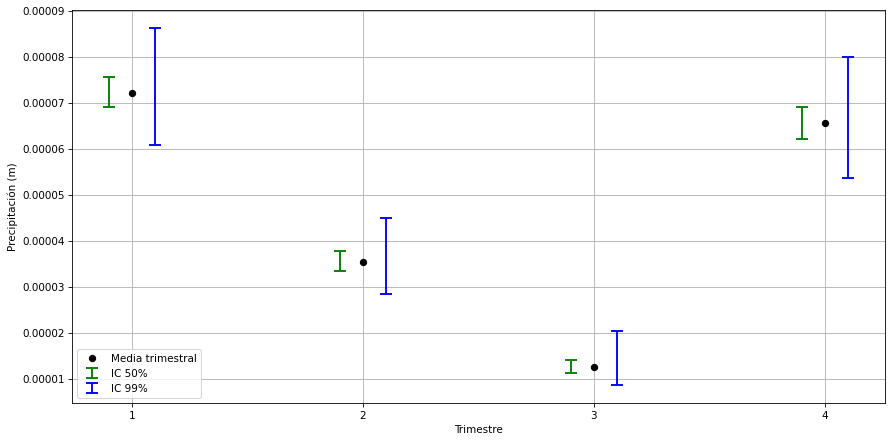

In [14]:
print('En tercer lugar representamos gráficamente los intervalos de confianza Bootstrap de la precipitación por trimestres.')
trimestres = tabla_precip['Trimestre'].tolist()
x_pos = np.arange(1, len(trimestres) + 1)
medias = tabla_precip['Media'].to_numpy(dtype=float)

delta = 0.10
lim_inf_50 = tabla_precip['IC 50%'].apply(lambda z: z[0]).to_numpy(dtype=float)
lim_sup_50 = tabla_precip['IC 50%'].apply(lambda z: z[1]).to_numpy(dtype=float)
lim_inf_99 = tabla_precip['IC 99%'].apply(lambda z: z[0]).to_numpy(dtype=float)
lim_sup_99 = tabla_precip['IC 99%'].apply(lambda z: z[1]).to_numpy(dtype=float)
from matplotlib.ticker import ScalarFormatter

fig = plt.figure(figsize=(12, 6))
plt.plot(x_pos, medias, 'o', color='black', markersize=6, label='Media trimestral')

yerr_50 = np.vstack((medias - lim_inf_50, lim_sup_50 - medias))
yerr_99 = np.vstack((medias - lim_inf_99, lim_sup_99 - medias))

plt.errorbar(x_pos - delta, medias, yerr=yerr_50, fmt='none', ecolor='green', elinewidth=1.8, capsize=6, capthick=1.8, label='IC 50%')
plt.errorbar(x_pos + delta, medias, yerr=yerr_99, fmt='none', ecolor='blue', elinewidth=1.8, capsize=6, capthick=1.8, label='IC 99%')

plt.xlabel('Trimestre')
plt.ylabel('Precipitación (m)')
plt.xticks(x_pos, trimestres)
plt.legend()
plt.grid()
ax_main = plt.gca()
fmt_x_main = ScalarFormatter(useOffset=False)
fmt_x_main.set_scientific(False)
fmt_y_main = ScalarFormatter(useOffset=False)
fmt_y_main.set_scientific(False)
ax_main.xaxis.set_major_formatter(fmt_x_main)
ax_main.yaxis.set_major_formatter(fmt_y_main)

plt.tight_layout()
plt.savefig(IMAGES_DIR / 'Gráfico 3.5： Intervalos de confianza Bootstrap de la precipitación por trimestres en celda 01.png', dpi=300, bbox_inches='tight')
plt.show()

En cuarto lugar representamos, para cada trimestre, la distribución bootstrap de la media junto con la distribución estimada, el IC 99%, la zona crítica al 50% y las bandas inferiores para IC 99% e IC 30%.


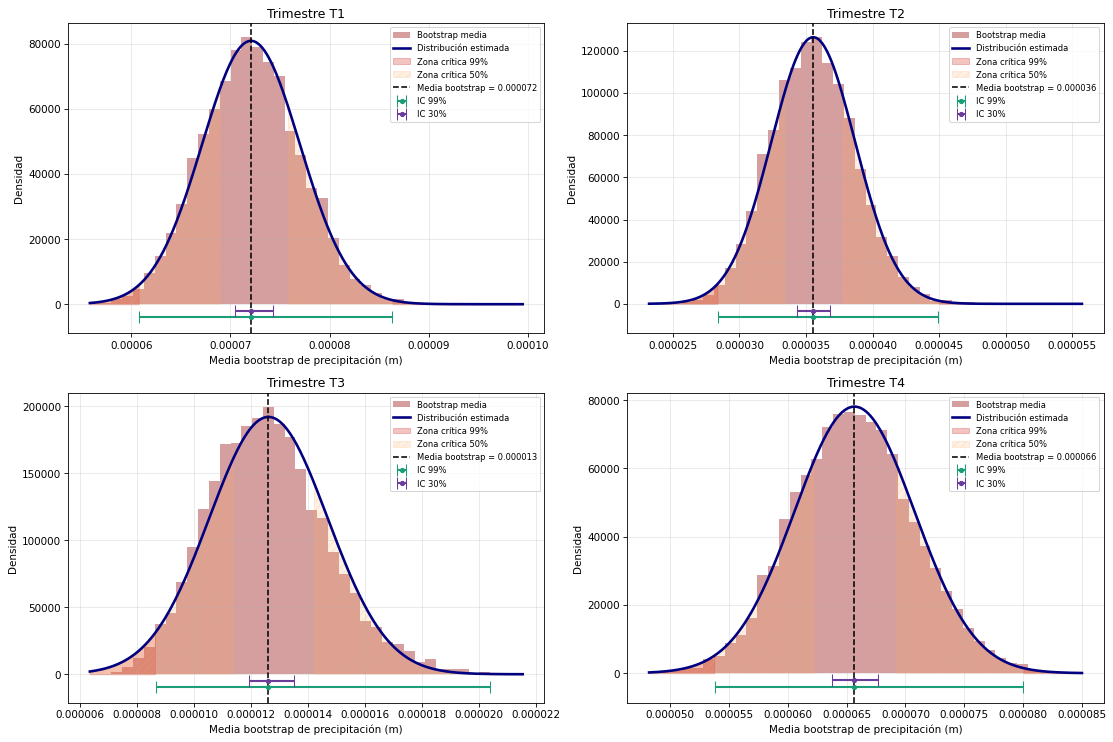

In [15]:
print('En cuarto lugar representamos, para cada trimestre, la distribución bootstrap de la media junto con la distribución estimada, el IC 99%, la zona crítica al 50% y las bandas inferiores para IC 99% e IC 30%.')
fig = plt.figure(2, figsize=(15, 10))
for idx, trimestre in enumerate(trimestres, start=1):
    valores_boot = dist_boot_precip_99[trimestre]
    mu_hat = np.mean(valores_boot)
    sigma_hat = np.std(valores_boot, ddof=1)

    lim_inf_99_t, lim_sup_99_t = tabla_precip.loc[tabla_precip['Trimestre'] == trimestre, 'IC 99%'].iloc[0]
    lim_inf_50_t, lim_sup_50_t = tabla_precip.loc[tabla_precip['Trimestre'] == trimestre, 'IC 50%'].iloc[0]
    lim_inf_30_t, lim_sup_30_t = tabla_precip.loc[tabla_precip['Trimestre'] == trimestre, 'IC 30%'].iloc[0]

    xs = np.linspace(np.min(valores_boot), np.max(valores_boot), 400)
    densidad_est = stats.norm.pdf(xs, loc=mu_hat, scale=sigma_hat)

    ax = plt.subplot(2, 2, idx)
    ax.hist(valores_boot, density=True, bins=40, color='brown', alpha=0.45, label='Bootstrap media')
    ax.plot(xs, densidad_est, color='navy', linewidth=2.5, label='Distribución estimada')

    xs_crit_99_izq = xs[xs < lim_inf_99_t]
    xs_crit_99_der = xs[xs > lim_sup_99_t]
    if xs_crit_99_izq.size > 0:
        ax.fill_between(xs_crit_99_izq, stats.norm.pdf(xs_crit_99_izq, loc=mu_hat, scale=sigma_hat), color='#d73027', alpha=0.28, label='Zona crítica 99%')
    if xs_crit_99_der.size > 0:
        ax.fill_between(xs_crit_99_der, stats.norm.pdf(xs_crit_99_der, loc=mu_hat, scale=sigma_hat), color='#d73027', alpha=0.28)

    xs_crit_50_izq = xs[xs < lim_inf_50_t]
    xs_crit_50_der = xs[xs > lim_sup_50_t]
    if xs_crit_50_izq.size > 0:
        ax.fill_between(xs_crit_50_izq, stats.norm.pdf(xs_crit_50_izq, loc=mu_hat, scale=sigma_hat), facecolor='#fdae61', edgecolor='#fdae61', alpha=0.18, hatch='///', label='Zona crítica 50%')
    if xs_crit_50_der.size > 0:
        ax.fill_between(xs_crit_50_der, stats.norm.pdf(xs_crit_50_der, loc=mu_hat, scale=sigma_hat), facecolor='#fdae61', edgecolor='#fdae61', alpha=0.18, hatch='///')

    ax.axvline(mu_hat, color='black', linestyle='--', linewidth=1.5, label=f'Media bootstrap = {mu_hat:.6f}')
    y_ic_99 = -0.05 * np.max(densidad_est)
    y_ic_30 = -0.025 * np.max(densidad_est)
    ax.errorbar(mu_hat, y_ic_99, xerr=np.array([[mu_hat - lim_inf_99_t], [lim_sup_99_t - mu_hat]]), fmt='o', color='#1b9e77', ecolor='#1b9e77', capsize=6, elinewidth=2.0, markersize=4, label='IC 99%')
    ax.errorbar(mu_hat, y_ic_30, xerr=np.array([[mu_hat - lim_inf_30_t], [lim_sup_30_t - mu_hat]]), fmt='o', color='#6a3d9a', ecolor='#6a3d9a', capsize=6, elinewidth=2.0, markersize=4, label='IC 30%')

    ax.set_ylim(bottom=2.2 * y_ic_99)
    ax.set_xlabel('Media bootstrap de precipitación (m)')
    ax.set_ylabel('Densidad')
    ax.set_title(f'Trimestre {trimestre}')
    ax.grid(alpha=0.3)
    fmt_x = ScalarFormatter(useOffset=False)
    fmt_x.set_scientific(False)
    fmt_y = ScalarFormatter(useOffset=False)
    fmt_y.set_scientific(False)
    ax.xaxis.set_major_formatter(fmt_x)
    ax.yaxis.set_major_formatter(fmt_y)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(IMAGES_DIR / 'Gráfico 3.6： Distribución bootstrap, distribución estimada, IC 50% y 99% y zonas críticas de precipitación por trimestres en celda 01.png', dpi=300, bbox_inches='tight')
plt.show()

In [16]:
print('En cuarto lugar evaluamos qué pares de trimestres solapan para cada nivel de confianza.')
solapes_por_ic = {}
for nivel_confianza in niveles_confianza:
    pares_solape = []
    etiqueta = f'IC {int(100 * nivel_confianza)}%'

    for i in range(len(tabla_precip)):
        for j in range(i + 1, len(tabla_precip)):
            a1, b1 = tabla_precip.loc[i, etiqueta]
            a2, b2 = tabla_precip.loc[j, etiqueta]
            if not (b1 < a2 or b2 < a1):
                pares_solape.append(f"{tabla_precip.loc[i, 'Trimestre']}-{tabla_precip.loc[j, 'Trimestre']}")

    solapes_por_ic[etiqueta] = set(pares_solape)

    if len(pares_solape) > 0:
        print(f"\nPares con solape para {etiqueta}: {', '.join(pares_solape)}")
    else:
        print(f"\nNo hay pares con solape para {etiqueta}.")

etiquetas = [f'IC {int(100 * nc)}%' for nc in niveles_confianza]
depende_precip = solapes_por_ic[etiquetas[0]] != solapes_por_ic[etiquetas[1]]

pares_50_precip = sorted(solapes_por_ic['IC 50%'])
pares_99_precip = sorted(solapes_por_ic['IC 99%'])
texto_50_precip = ', '.join(pares_50_precip) if len(pares_50_precip) > 0 else 'ninguno'
texto_99_precip = ', '.join(pares_99_precip) if len(pares_99_precip) > 0 else 'ninguno'

if depende_precip:
    print('\nConclusión: para precipitación, la respuesta sí depende del nivel de confianza.')
    interpretacion_precip = 'La lista de solapes cambia entre 50% y 99%, por lo que el resultado inferencial depende del nivel de confianza.'
else:
    print('\nConclusión: para precipitación, la respuesta no depende del nivel de confianza.')
    interpretacion_precip = 'La coincidencia de solapes en ambos niveles indica estabilidad de la conclusión frente al cambio de confianza.'

print("\nAnálisis del subapartado 3.3 - IC bootstrap de la media de precipitación por trimestres (celda 01) y evaluación de solapes para 50% y 99%:\n"
      f"Con un nivel de confianza del 50%, los pares con solape son: {texto_50_precip}.\n"
      f"Con un nivel de confianza del 99%, los pares con solape son: {texto_99_precip}.\n"
      f"{interpretacion_precip}\n"
      "La comparación visual en barras de error confirma este resultado al mostrar de forma explícita los tramos de intersección entre intervalos.")

En cuarto lugar evaluamos qué pares de trimestres solapan para cada nivel de confianza.

Pares con solape para IC 50%: T1-T4

Pares con solape para IC 99%: T1-T4

Conclusión: para precipitación, la respuesta no depende del nivel de confianza.

Análisis del subapartado 3.3 - IC bootstrap de la media de precipitación por trimestres (celda 01) y evaluación de solapes para 50% y 99%:
Con un nivel de confianza del 50%, los pares con solape son: T1-T4.
Con un nivel de confianza del 99%, los pares con solape son: T1-T4.
La coincidencia de solapes en ambos niveles indica estabilidad de la conclusión frente al cambio de confianza.
La comparación visual en barras de error confirma este resultado al mostrar de forma explícita los tramos de intersección entre intervalos.


In [17]:
print('Síntesis global del apartado 3:')

if depende_irrad or depende_temp or depende_precip:
    conclusion_global = ('Al menos una de las variables modifica sus pares con solape al pasar de 50% a 99%, '
                         'por lo que la respuesta general sí depende del nivel de confianza.')
else:
    conclusion_global = ('En este conjunto de datos, los pares con solape se mantienen al pasar de 50% a 99% '
                         'en irradiación, temperatura y precipitación, por lo que la respuesta general no depende '
                         'del nivel de confianza.')

print("\nEn los tres subapartados se ha aplicado el mismo procedimiento bootstrap BCa para comparar medias trimestrales mediante IC al 50% y al 99%.\n"
      "La lectura conjunta de las seis figuras permite validar las tablas de solape obtenidas en cada caso.\n"
      f"{conclusion_global}\n"
      "En términos metodológicos, las barras de error incorporadas en los gráficos de evaluación mejoran la interpretación de intervalos estrechos y facilitan la comparación entre trimestres.")

Síntesis global del apartado 3:

En los tres subapartados se ha aplicado el mismo procedimiento bootstrap BCa para comparar medias trimestrales mediante IC al 50% y al 99%.
La lectura conjunta de las seis figuras permite validar las tablas de solape obtenidas en cada caso.
En este conjunto de datos, los pares con solape se mantienen al pasar de 50% a 99% en irradiación, temperatura y precipitación, por lo que la respuesta general no depende del nivel de confianza.
En términos metodológicos, las barras de error incorporadas en los gráficos de evaluación mejoran la interpretación de intervalos estrechos y facilitan la comparación entre trimestres.
